In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries and KIND framework files --!

import torch
import numpy as np
from   matplotlib import pyplot as plt

import kind
import utils_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--data_name', 'SRF gun simulation',
        '--data_dir', '../../data/delay',
        '--data_file', 'gun_sim',
        '--data_nsample', '250',
        '--data_scale_min', '-1',
        '--data_scale_max', '1',
        '--data_train_size', '0.6',
        '--data_test_size', '0.5',

        '--feature_dim', '0,1',
        '--target_dim', '0',
        '--lookback_nsample', '96',
        '--forecast_nsample', '48',

        '--batch_size', '64',
        '--learning_rate', '0.001',
        '--weight_decay', '0.0001',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/delay',

        '--seg_nsample_stat', '24',
        '--seg_nsample_trans', '12',
        '--fun_stat', '{"sin": 5, "cos": 5}',
        '--fun_trans', '{"data": 8}',
    ]
)

In [3]:
dataset = utils_data.dataset_factory().create_dataset(args)

In [4]:
model = kind.model(args)

In [5]:
model.fit(dataset)

>>> train stationary mean >>>
	epoch 1 losses: train=0.356886, valid=0.026764, test=0.027282
	validation loss decreased (inf -> 0.026764), saving model ...
	epoch 2 losses: train=0.352976, valid=0.026706, test=0.027184
	validation loss decreased (0.026764 -> 0.026706), saving model ...
	epoch 3 losses: train=0.352689, valid=0.026877, test=0.027445
	early stopping counter: 1 out of 10
	epoch 4 losses: train=0.348189, valid=0.030890, test=0.031899
	early stopping counter: 2 out of 10
	epoch 5 losses: train=0.292486, valid=0.029926, test=0.030335
	early stopping counter: 3 out of 10
	epoch 6 losses: train=0.216904, valid=0.025794, test=0.027171
	validation loss decreased (0.026706 -> 0.025794), saving model ...
	epoch 7 losses: train=0.160417, valid=0.022804, test=0.024474
	validation loss decreased (0.025794 -> 0.022804), saving model ...
	epoch 8 losses: train=0.069170, valid=0.011548, test=0.011762
	validation loss decreased (0.022804 -> 0.011548), saving model ...
	epoch 9 losses: tra

In [6]:
model.eval()
_, _, data_loader = dataset.load(data_type='stat')

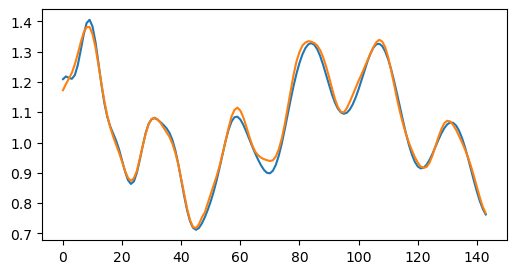

In [7]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,3))
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])
        plt.show()

        break

In [8]:
model.train()
model.fit_next()
model.fit(dataset)

>>> train stationary uncertainty >>>
	epoch 1 losses: train=0.451852, valid=0.183926, test=0.179741
	validation loss decreased (inf -> 0.183926), saving model ...
	epoch 2 losses: train=0.010644, valid=-0.233854, test=-0.224330
	validation loss decreased (0.183926 -> -0.233854), saving model ...
	epoch 3 losses: train=-0.444328, valid=-0.467289, test=-0.462624
	validation loss decreased (-0.233854 -> -0.467289), saving model ...
	epoch 4 losses: train=-0.633867, valid=-0.508462, test=-0.490083
	validation loss decreased (-0.467289 -> -0.508462), saving model ...
	epoch 5 losses: train=-0.690778, valid=-0.555851, test=-0.530966
	validation loss decreased (-0.508462 -> -0.555851), saving model ...
	epoch 6 losses: train=-0.729660, valid=-0.566789, test=-0.537449
	validation loss decreased (-0.555851 -> -0.566789), saving model ...
	epoch 7 losses: train=-0.759715, valid=-0.591772, test=-0.559277
	validation loss decreased (-0.566789 -> -0.591772), saving model ...
	epoch 8 losses: train=

In [9]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

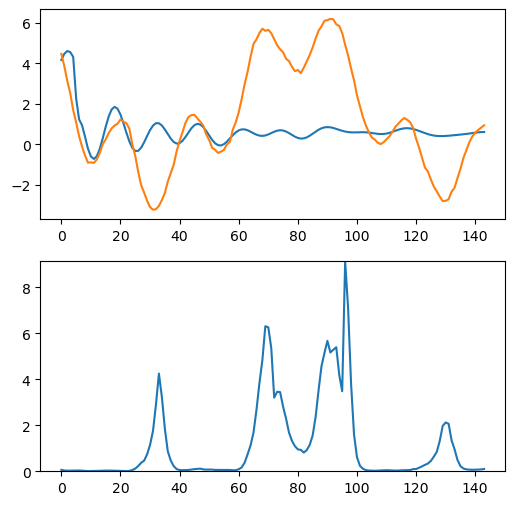

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_uncertain = model_output[2]
        stat_uncertain = torch.exp(stat_uncertain) + 1e-6
        stat_uncertain_max = torch.max(stat_uncertain)
        stat_uncertain_max = 0.1 if stat_uncertain_max < 0.1 else stat_uncertain_max

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1])
        plt.plot(stat[0, :, :1])

        plt.subplot(2,1,2)
        plt.plot(stat_uncertain[0, :, :1])
        plt.ylim((0., stat_uncertain_max))

        plt.show()

        break